# **ConnectX using Double Q-Learning** 

**Introduction**

ConnectX is a generalized version of the popular Connect Four game, where players take turns dropping pieces into a grid, aiming to align a specific number of their pieces in a row, column, or diagonal. Reinforcement Learning (RL) techniques, particularly Double Q-Learning, can be used to develop an agent that learns optimal moves through self-play and experience. This project implements a Double Q-Learning approach to train an AI agent to play.



**Problem Formulation**

* States: Representing the current game board configuration.
* Actions: Columns where a piece can be dropped.
* Rewards: +1 for winning moves, -1 for losing moves, and 0 otherwise
* Transitions: The opponent’s move affects the next state.


**Reward Function**

* +1 for winning moves
* -1 for losing moves
* 0 for intermediate moves



**Training Process**

* The agent self-plays to learn optimal moves.
* Training runs for N episodes with decaying epsilon.
* Q-values are updated based on game outcomes.
* The trained Q-tables are used for inference in test games.




**Double Q-Learning**

Q-Learning is a value-based RL algorithm that learns an optimal policy by updating Q-values through the Bellman equation. However, Double Q-Learning (DQL) addresses the overestimation bias in standard Q-learning by maintaining two separate Q-tables (Q1 and Q2), updating them alternately. This prevents overly optimistic value estimates, leading to better performance.

**Algorithm Steps:**

1. Initialize Q1 and Q2 tables with zeros.
2. Choose an action using an epsilon-greedy policy based on Q1 + Q2.
3. Execute the action and observe the reward and next state.
4. Update Q-values:
5. With probability 0.5, update Q1 using Q2’s action selection. Otherwise, update Q2 using Q1’s action selection.

Repeat until convergence or a predefined number of episodes.



# Install libraries

In [1]:
!pipip install stable-baselines3==1.3.0 kaggle-environments==1.14.0 > /dev/null 2>&1

# Import libraries

In [2]:
import sys
import time
import hashlib
import numpy as np
import gym
import random
import pickle
import zlib
import base64 as b64
from random import choice
from kaggle_environments import evaluate, make, utils
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

/usr/local/lib/python3.10/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.10/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.10/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

# Define useful classes

NOTE: It's not easy to generate a Q-Table with all possible states; and even if I can do so, the huge number of states will cost much of memory. So, I use the approach that dynamically adding newly discovered states into an object of QTable class created below

In [3]:
class TrainingProgress:
    """
    Class to track and display the training progress. This class was created 
    to avoid compatibility issues with the `tqdm` library in Notebooks.
    """
    def __init__(self, total, prefix=''):
        self.total = total
        self.prefix = prefix
        self.start_time = time.time()

    def update(self, current):
        current = min(current, self.total)
        remaining = self.total - current
        elapsed_time = time.time() - self.start_time

        line = (
            f"{self.prefix} Current: {current}/{self.total} "
            f"Remaining: {remaining} "
            f"Elapsed: {elapsed_time:.2f}"
        )
        print(f'\r{line}', end='', flush=True)

    def finish(self):
        self.update(self.total)
        print()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [4]:
class ConnectX(gym.Env):
    def __init__(self, switch_prob=0.5):
        self.env = make('connectx', debug=True)
        self.pair = [None, 'random']
        self.trainer = self.env.train(self.pair)
        self.switch_prob = switch_prob
        
        # Define required gym fields (examples):
        config = self.env.configuration
        self.action_space = gym.spaces.Discrete(config.columns)
        self.observation_space = gym.spaces.Discrete(config.columns * config.rows)

    def switch_trainer(self):
        self.pair = self.pair[::-1]
        self.trainer = self.env.train(self.pair)

    def step(self, action):
        return self.trainer.step(action)
    
    def reset(self):
        if random.uniform(0, 1) < self.switch_prob:
            self.switch_trainer()
        return self.trainer.reset()
    
    def render(self, **kwargs):
        return self.env.render(**kwargs)

In [5]:
class DoubleQTable:
    def __init__(self, action_space, config):
        self.Q1 = dict()
        self.Q2 = dict()
        self.action_space = action_space
        self.config = config
        
    def add_item(self, state_key):
        self.Q1[state_key] = np.zeros(self.action_space.n)
        self.Q2[state_key] = np.zeros(self.action_space.n)

    def generate_key(self, state):
        board = state['board'][:]
        board.append(state.mark)
        state_key = np.array(board).astype(str)
        state_key = hex(int(''.join(state_key), 3))[2:]
        return state_key

    def select_action(self, state, epsilon):
        Q1, Q2 = self(state)
        
        if random.uniform(0, 1) < epsilon:
            # Exploration: Choose a random valid action
            action = choice([c for c in range(self.action_space.n) if state['board'][c] == 0])
        else:
            # Exploitation: Choose the action with the highest Q value
            selected_items = [
                (Q1[j] + Q2[j]) if state['board'][j] == 0 else -1e7
                for j in range(self.action_space.n)
            ]
            action = int(np.argmax(selected_items))
        return action

    def update_q_values(self, state, action, reward, next_state):
        Q1, Q2 = self(state)
        Q1_next, Q2_next = self(next_state)
        
        if random.uniform(0, 1) < 0.5:
            # Update Q1
            next_action = np.argmax(Q1_next)  # Action based on Q1
            Q1[action] += self.config["alpha"] * (reward + self.config["gamma"] * Q2_next[next_action] - Q1[action])
        else:
            # Update Q2
            next_action = np.argmax(Q2_next)  # Action based on Q2
            Q2[action] += self.config["alpha"] * (reward + self.config["gamma"] * Q1_next[next_action] - Q2[action])

    def __call__(self, state):
        # Returns the Q-tables for the state
        state_key = self.generate_key(state)
        if state_key not in self.Q1:
            self.add_item(state_key)
        return self.Q1[state_key], self.Q2[state_key]

def calculate_reward(done, reward, config):
    if done:
        if reward == 1:  # Won
            return config["reward_win"]
        elif reward == 0:  # Lost
            return config["reward_loss"]
        else:  # Draw
            return config["reward_draw"]
    return config["reward_step"]



# Create ConnectX environment

In [6]:
env = ConnectX()

# Train the agent with hyper parameters

The agent is being trained over 50,000 episodes with decaying learning rate (alpha) and exploration rate (epsilon). The Q-values are updated using the Double Q-learning technique, which maintains two separate Q-tables (Q1 and Q2) to reduce overestimation bias while tracking performance metrics such as total rewards, average rewards, and exploration rate decay.



In [7]:
config = {
    # "alpha": 0.1,
    "alpha": 0.3,
    # "gamma": 0.6,
    "gamma": 0.7,
    "epsilon": 0.99,
    "min_epsilon": 0.1,
    "episodes": 40000,

    "alpha_decay_step": 1000,
    "alpha_decay_rate": 0.9,
    "epsilon_decay_rate": 0.9999,

    "reward_win": 20,
    "reward_loss": -20,
    "reward_draw": 10,
    "reward_step": -0.05
}

epsilon = config["epsilon"]
all_epochs = []
all_total_rewards = []
all_avg_rewards = []
all_qtable_rows = []
all_epsilons = []

double_q_table = DoubleQTable(
    action_space=env.action_space,
    config=config
)
progress = TrainingProgress(
    total=config["episodes"],
    prefix="Training progress"
)

for i in range(config["episodes"]):
    state = env.reset()
    epsilon = max(config["min_epsilon"], epsilon * config["epsilon_decay_rate"])
    epochs, total_rewards = 0, 0
    done = False

    while not done:
        # Select the action randomly or via the Q-table
        action = double_q_table.select_action(state, epsilon)
        
        next_state, reward, done, _ = env.step(action)
        reward = calculate_reward(done, reward, config)
        double_q_table.update_q_values(state, action, reward, next_state)

        state = next_state
        epochs += 1
        total_rewards += reward

    all_epochs.append(epochs)
    all_total_rewards.append(total_rewards)
    avg_rewards = np.mean(all_total_rewards[max(0, i-200):(i+1)])
    all_avg_rewards.append(avg_rewards)
    all_qtable_rows.append(len(double_q_table.Q1))
    all_epsilons.append(epsilon)

    if (i+1) % config["alpha_decay_step"] == 0:
        config["alpha"] *= config["alpha_decay_rate"]

    progress.update(i)

progress.finish()

Training progress Current: 40000/40000 Remaining: 0 Elapsed: 2415.677393


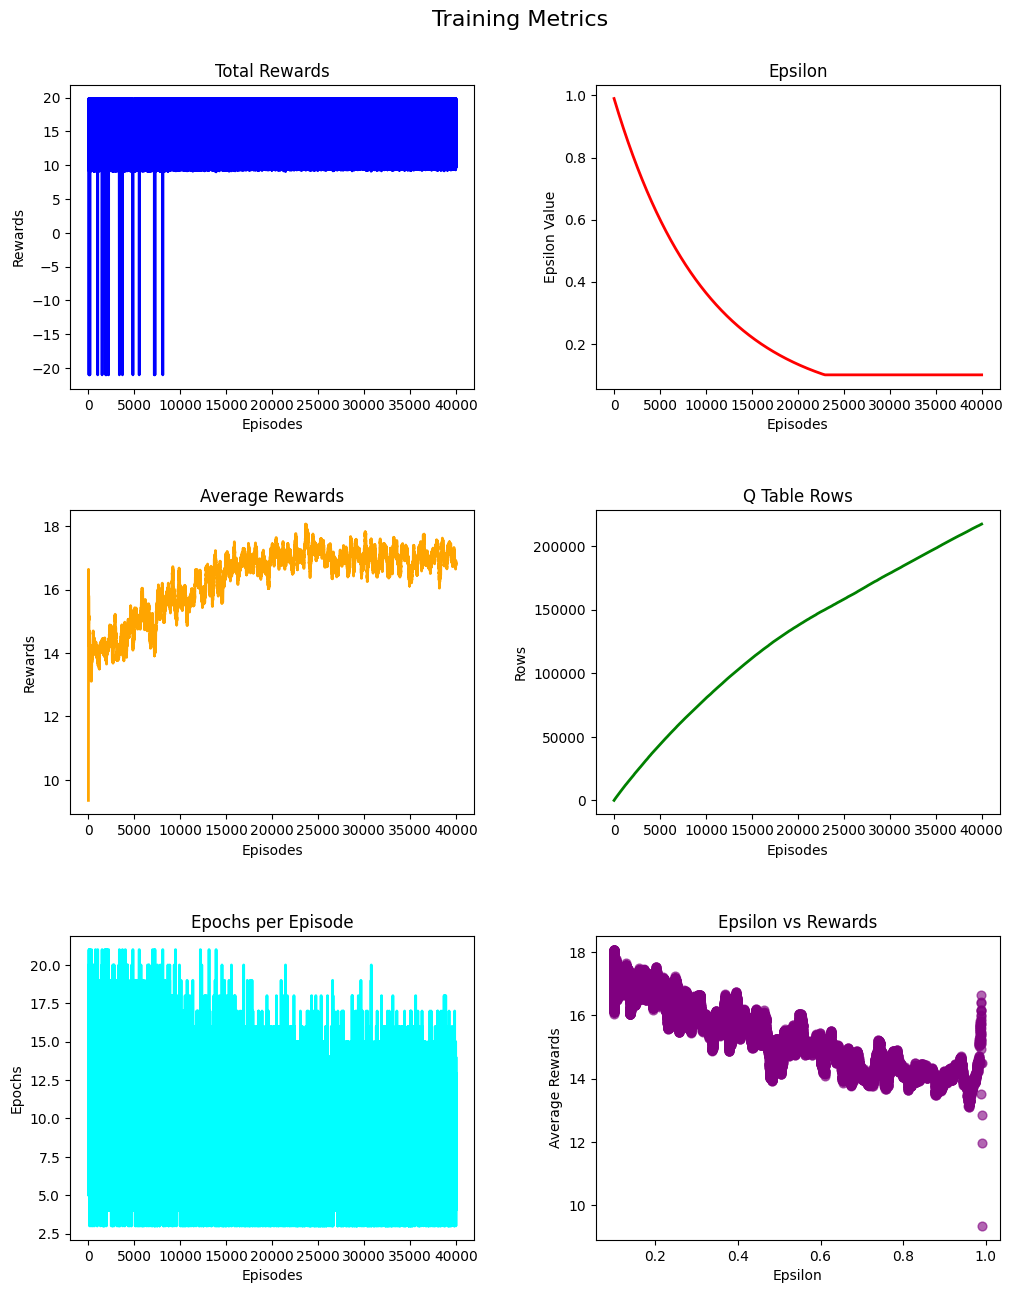

In [15]:
# Layout setup
fig = plt.figure(figsize=(12, 15))
gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1], hspace=0.4, wspace=0.3)

# Subplot 1: Total Rewards
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(range(len(all_total_rewards)), all_total_rewards, color='blue', linewidth=2)
ax1.set_title("Total Rewards")
ax1.set_xlabel("Episodes")
ax1.set_ylabel("Rewards")

# Subplot 2: Epsilon
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(range(len(all_epsilons)), all_epsilons, color='red', linewidth=2)
ax2.set_title("Epsilon")
ax2.set_xlabel("Episodes")
ax2.set_ylabel("Epsilon Value")

# Subplot 3: Average Rewards
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(range(len(all_avg_rewards)), all_avg_rewards, color='orange', linewidth=2)
ax3.set_title("Average Rewards")
ax3.set_xlabel("Episodes")
ax3.set_ylabel("Rewards")

# Subplot 4: Q Table Rows
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(range(len(all_qtable_rows)), all_qtable_rows, color='green', linewidth=2)
ax4.set_title("Q Table Rows")
ax4.set_xlabel("Episodes")
ax4.set_ylabel("Rows")

# Subplot 5: Epochs
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(range(len(all_epochs)), all_epochs, color='cyan', linewidth=2)
ax5.set_title("Epochs per Episode")
ax5.set_xlabel("Episodes")
ax5.set_ylabel("Epochs")

# Subplot 6: Epsilon vs Rewards
ax6 = fig.add_subplot(gs[2, 1])
ax6.scatter(all_epsilons, all_avg_rewards, color='purple', alpha=0.6, s=40)
ax6.set_title("Epsilon vs Rewards")
ax6.set_xlabel("Epsilon")
ax6.set_ylabel("Average Rewards")

plt.suptitle("Training Metrics", fontsize=16, y=0.93)
plt.show()

# Create an agent

Now we extract the best actions from the trained Double Q-learning tables (Q1 and Q2), then serializes, compresses, and encodes them using pickle, zlib, and Base64. It defines a standalone agent function (dql_agent) that can decode and use these tables for action selection. The agent chooses between Q1 and Q2 randomly, ensuring stability in decision-making while handling invalid actions. This setup allows for efficient storage and deployment of the trained Q-learning model.

In [16]:
tmp_dict_q_table_1 = double_q_table.Q1.copy()
tmp_dict_q_table_2 = double_q_table.Q2.copy()
dict_q_table_1 = dict()
dict_q_table_2 = dict()

# Fill the Q tables with the best actions 
for k in tmp_dict_q_table_1:
    if np.count_nonzero(tmp_dict_q_table_1[k]) > 0:
        dict_q_table_1[k] = int(np.argmax(tmp_dict_q_table_1[k]))

for k in tmp_dict_q_table_2:
    if np.count_nonzero(tmp_dict_q_table_2[k]) > 0:
        dict_q_table_2[k] = int(np.argmax(tmp_dict_q_table_2[k]))

# Serialize, compress and encoding data
serialized_q_table_1 = pickle.dumps(dict_q_table_1)
serialized_q_table_2 = pickle.dumps(dict_q_table_2)
compressed_q_table_1 = zlib.compress(serialized_q_table_1)
compressed_q_table_2 = zlib.compress(serialized_q_table_2)
base64_q_table_1 = b64.b64encode(compressed_q_table_1).decode('utf-8')
base64_q_table_2 = b64.b64encode(compressed_q_table_2).decode('utf-8')

dql_agent = '''def dql_agent(observation, configuration):
    from random import choice
    import numpy as np
    import pickle
    import zlib
    import base64 as b64

    # Base64 encoded compressed Q1 and Q2 tables
    serialized_q_table_1 = "''' + base64_q_table_1 + '''"
    serialized_q_table_2 = "''' + base64_q_table_2 + '''"
    q_table_1 = pickle.loads(zlib.decompress(b64.b64decode(serialized_q_table_1)))
    q_table_2 = pickle.loads(zlib.decompress(b64.b64decode(serialized_q_table_2)))

    board = observation.board[:]
    board.append(observation.mark)
    state_key = list(map(str, board))
    state_key = hex(int(''.join(state_key), 3))[2:]

    if state_key not in q_table_1 or state_key not in q_table_2:
        return choice([c for c in range(configuration.columns) if observation.board[c] == 0])

    Q1 = q_table_1[state_key]
    Q2 = q_table_2[state_key]

    if np.random.uniform(0, 1) < 0.5:
        action = Q1
    else:
        action = Q2

    if observation.board[action] != 0:
        return choice([c for c in range(configuration.columns) if observation.board[c] == 0])

    return action
'''


In [17]:
with open('submission.py', 'w') as f:
    f.write(dql_agent)

# Evaluating agent performance

Evaluation of the trained Double Q-learning agent (dql_agent) by playing against:

1. A random agent (baseline performance check).


It computes the average reward from 10 matches against each opponent to measure the agent’s effectiveness.


In [18]:
import importlib
import submission
importlib.reload(submission)
from submission import dql_agent

In [20]:
def mean_reward(rewards):
    return sum(r[0] for r in rewards) / float(len(rewards))

# Run multiple episodes to estimate its performance.
print("My Agent vs Random Agent:", mean_reward(evaluate("connectx", [dql_agent, "random"], num_episodes=10, debug=True)))


My Agent vs Random Agent: 0.8
